# Demand Pattern Clustering

Before developing forecasting models, products will be segmented according to their demand behavior. Although the simulated dataset was generated using predefined demand patterns, this information would not be available in a real production environment.

In practice, demand profiles are hidden within the historical sales data and must be discovered through analysis. For this reason, an unsupervised clustering step will be performed to identify groups of products with similar demand characteristics.

The resulting clusters will then be used to train specialized forecasting models, allowing each model to focus on a more homogeneous demand pattern and potentially achieve better forecasting performance than a single model trained across all products.


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
from matplotlib import pyplot as plt
from sklearn.mixture import GaussianMixture

np.random.seed(42)

df = pd.read_csv('../data/demand_stock.csv', parse_dates=['date'])
print(df.shape)
df.head()

(43840, 14)


,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory
0,2020-01-01,1,group_1_steady,steady,33,384,0,0,38,4,38,190,456,417
1,2020-01-02,1,group_1_steady,steady,31,353,0,0,38,4,38,190,456,417
2,2020-01-03,1,group_1_steady,steady,42,311,0,0,38,4,38,190,456,417
3,2020-01-04,1,group_1_steady,steady,43,268,0,0,38,4,38,190,456,417
4,2020-01-05,1,group_1_steady,steady,24,244,0,0,38,4,38,190,456,417


In [ ]:

def create_features(df):
    """
    Create SKU-level features for demand clustering.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
        One row per SKU.
    """

    features = []

    for sku_id, sku_df in df.groupby("sku_id"):

        sales = sku_df["sales"].values
        mean_sales = np.mean(sales)
        std_sales = np.std(sales)

        coefficient_of_variation = (
            std_sales / mean_sales
            if mean_sales > 0
            else 0
        )

        zero_sales_rate = np.mean(sales == 0)
        stockout_rate = sku_df["stockout_flag"].mean()

        # Intermittency
        non_zero_idx = np.where(sales > 0)[0]

        if len(non_zero_idx) > 1:
            intermittency = np.mean(np.diff(non_zero_idx))
        else:
            intermittency = len(sales)

        # Trend
        x = np.arange(len(sales))

        try:
            trend = linregress(x, sales).slope
        except:
            trend = 0

        # Seasonality strength
        monthly_sales = (
            sku_df
            .set_index("date")["sales"]
            .resample("ME")
            .sum()
        )

        if len(monthly_sales) >= 24:

            seasonal_profile = (
                monthly_sales
                .groupby(monthly_sales.index.month)
                .mean()
            )

            seasonality_strength = (
                seasonal_profile.std()
                / monthly_sales.mean()
                if monthly_sales.mean() > 0
                else 0
            )

        else:
            seasonality_strength = 0

        # Additional features
        p90_sales = np.percentile(sales, 90)
        max_sales = np.max(sales)

        demand_burstiness = (
            max_sales / mean_sales
            if mean_sales > 0
            else 0
        )

        features.append({
            "sku_id": sku_id,
            "mean_sales": mean_sales,
            "std_sales": std_sales,
            "coefficient_of_variation": coefficient_of_variation,
            "zero_sales_rate": zero_sales_rate,
            "seasonality_strength": seasonality_strength,
            "trend": trend,
            "stockout_rate": stockout_rate,
            "intermittency": intermittency,
            "p90_sales": p90_sales,
            "demand_burstiness": demand_burstiness
        })

    df_features = pd.DataFrame(features)
    return df_features

df_features = create_features(df)
print(df_features.shape)
df_features.head()

(20, 11)


,sku_id,mean_sales,std_sales,coefficient_of_variation,zero_sales_rate,seasonality_strength,trend,stockout_rate,intermittency,p90_sales,demand_burstiness
0,1,37.799726,6.931794,0.183382,0.0,0.033183,-0.000278,0.0,1.0,47.0,1.587313
1,2,53.708942,9.743431,0.181412,0.0,0.029523,0.000044,0.0,1.0,66.0,1.582604
2,3,26.786953,4.794476,0.178986,0.0,0.031793,-0.000108,0.0,1.0,33.0,1.642591
3,4,55.410128,10.037028,0.181141,0.0,0.027521,-0.000209,0.0,1.0,68.0,1.642299
4,5,41.593978,7.408771,0.178121,0.0,0.028437,-0.000242,0.0,1.0,51.0,1.706978


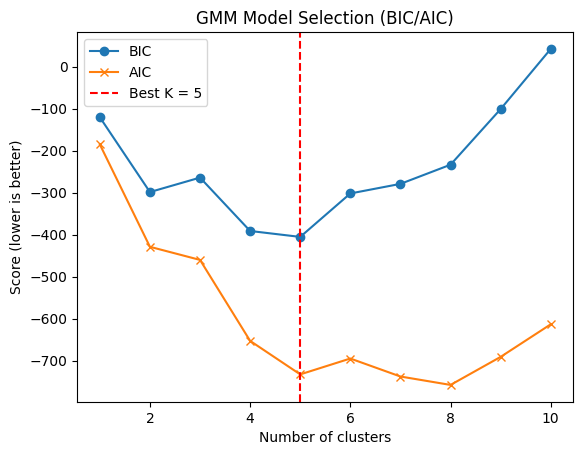

Best k: 5


In [3]:

max_k = 10
bic_scores = []
aic_scores = []
k_range = range(1, max_k + 1)
X = df_features[['mean_sales', 'std_sales', 'coefficient_of_variation',
       'zero_sales_rate', 'seasonality_strength', 'trend', 'stockout_rate',
       'intermittency', 'p90_sales', 'demand_burstiness']]

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(X)

    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))

best_k = k_range[np.argmin(bic_scores)]

# Plot "elbow-style" BIC curve
plt.figure()
plt.plot(k_range, bic_scores, marker="o", label="BIC")
plt.plot(k_range, aic_scores, marker="x", label="AIC")
plt.axvline(best_k, linestyle="--", color="red", label=f"Best K = {best_k}")
plt.title("GMM Model Selection (BIC/AIC)")
plt.xlabel("Number of clusters")
plt.ylabel("Score (lower is better)")
plt.legend()
plt.show()

print('Best k:', best_k)


The chart shows the Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC) values obtained when fitting Gaussian Mixture Models with different numbers of clusters. Both metrics evaluate the trade-off between model fit and complexity, where lower values indicate a better balance between accurately representing the data and avoiding overfitting.

As the number of clusters increases, both metrics initially improve, indicating that additional clusters help capture meaningful demand patterns. The lowest BIC value is reached at **K = 5**, suggesting that a five-cluster solution provides the best compromise between model complexity and explanatory power. Beyond this point, BIC begins to deteriorate, indicating that additional clusters introduce unnecessary complexity without a proportional improvement in fit. Therefore, five clusters were selected for the subsequent demand segmentation and forecasting stages.


In [4]:
final_gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=42
)

final_gmm.fit(X)


,n_components,5
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [5]:
df_features['cluster'] = final_gmm.fit_predict(X)
df_features.head()

,sku_id,mean_sales,std_sales,coefficient_of_variation,zero_sales_rate,seasonality_strength,trend,stockout_rate,intermittency,p90_sales,demand_burstiness,cluster
0,1,37.799726,6.931794,0.183382,0.0,0.033183,-0.000278,0.0,1.0,47.0,1.587313,0
1,2,53.708942,9.743431,0.181412,0.0,0.029523,0.000044,0.0,1.0,66.0,1.582604,4
2,3,26.786953,4.794476,0.178986,0.0,0.031793,-0.000108,0.0,1.0,33.0,1.642591,2
3,4,55.410128,10.037028,0.181141,0.0,0.027521,-0.000209,0.0,1.0,68.0,1.642299,4
4,5,41.593978,7.408771,0.178121,0.0,0.028437,-0.000242,0.0,1.0,51.0,1.706978,0


In [6]:
df_features.cluster.value_counts(normalize=True)

cluster
0    0.25
4    0.25
2    0.25
1    0.15
3    0.10
Name: proportion, dtype: float64

In [7]:
df = df.merge(df_features[['sku_id', 'cluster']], on='sku_id', how='left')
print(df.shape)
df.head()

(43840, 15)


,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory,cluster
0,2020-01-01,1,group_1_steady,steady,33,384,0,0,38,4,38,190,456,417,0
1,2020-01-02,1,group_1_steady,steady,31,353,0,0,38,4,38,190,456,417,0
2,2020-01-03,1,group_1_steady,steady,42,311,0,0,38,4,38,190,456,417,0
3,2020-01-04,1,group_1_steady,steady,43,268,0,0,38,4,38,190,456,417,0
4,2020-01-05,1,group_1_steady,steady,24,244,0,0,38,4,38,190,456,417,0


In [8]:
df.groupby(["category", "cluster"])["sku_id"].nunique().reset_index(name="count")


,category,cluster,count
0,group_1_steady,0,2
1,group_1_steady,2,1
2,group_1_steady,4,2
3,group_2_seasonal,0,1
4,group_2_seasonal,2,1
5,group_2_seasonal,4,3
6,group_3_noise,0,2
7,group_3_noise,2,1
8,group_3_noise,3,2
9,group_4_sparse,1,3


Although the synthetic dataset was generated with four predefined demand patterns (steady, seasonal, high-variability, and sparse), the Gaussian Mixture Model was trained using statistical features extracted from the observed sales history rather than the original labels. As a result, the clustering algorithm groups products according to the similarities it detects in the feature space, which may differ from the categories used during data generation.

In addition, inventory constraints and stockout events introduce demand censoring, causing the observed sales patterns to deviate from the underlying demand process. For example, a seasonal SKU with frequent stockouts may appear less seasonal than expected, while a noisy SKU with relatively stable sales may resemble a steady-demand product. Consequently, some overlap between the original categories and the clusters identified by the Gaussian Mixture Model is expected and reflects the fact that the clustering process is driven by observed behavior rather than by the simulated demand labels.


In [9]:
df.to_csv('../data/clusters.csv', index=False)